# **House Price Intelligence**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/train.csv")

## **Step 1: Dataset Understanding**

In [20]:
# How many rows and columns are present?
# Rows = houses
# Columns = features about houses

df.shape

(1460, 81)

## **Step 2: Understanding Data Types**

In [21]:
# first 5 rows 
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [22]:
# Check column names, data types, and missing values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## **Step 3: check Missing Values**

In [41]:
# Count missing values in every column
# Sort from highest missing to lowest
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)
print(missing_values)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64


## **Step 4: List All Columns**

In [24]:
# Display all column names 

df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## **Step 5: Understand Target Variable**

In [25]:
# statistical summary of SalePrice 
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## **Step 6 : Visualise House Price**

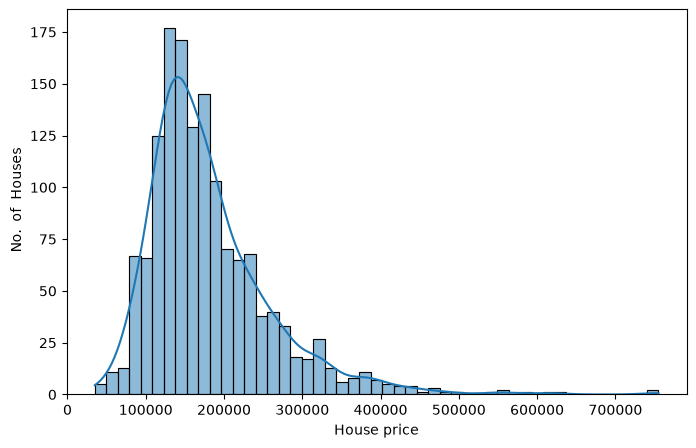

In [34]:
# Check distribution of house prices 

plt.figure(figsize=(8,5))
sns.histplot(
    data = df ,
    x="SalePrice",
    kde = True
)
plt.xlabel("House price")
plt.ylabel(" No.  of  Houses")
plt.show()

## **Step 7: Find Numerical Columns**

In [ ]:
# Purpose:
# Find all columns containing numbers.
# These columns can be used for calculations,
# correlations and outlier detection.

numerical_columns = df.select_dtypes(
    include=["int64","float64"]
).columns

print(numerical_columns)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')


## **Columns That May Affect SalePrice**

### House Condition : Directly reflects construction quality and maintenance.
- OverallQual → Overall material and finishing quality of the house.
- OverallCond → Current condition and upkeep of the property.

---

### House Size : Larger houses generally sell for higher prices.
- LotArea → Total land area of the property.
- LotFrontage → Width of the property facing the road.
- GrLivArea → Total above-ground living space.
- 1stFlrSF → First floor area.
- 2ndFlrSF → Second floor area.
- TotalBsmtSF → Total basement area.

---

### Age : Newer or renovated houses are usually more valuable.
- YearBuilt → Year the house was originally constructed.
- YearRemodAdd → Year of the most recent renovation/remodel.

---

### Bathrooms : More bathrooms improve convenience and market value.
- FullBath → Full bathrooms above ground.
- HalfBath → Half bathrooms above ground.
- BsmtFullBath → Full bathrooms in basement.
- BsmtHalfBath → Half bathrooms in basement.

---

### Bedrooms & Rooms : More usable rooms increase functionality.
- BedroomAbvGr → Bedrooms above ground level.
- TotRmsAbvGrd → Total rooms above ground (excluding bathrooms).

---

### Garage : Bigger and newer garages are attractive to buyers.
- GarageCars → Number of vehicles the garage can hold.
- GarageArea → Total garage size in square feet.
- GarageYrBlt → Year the garage was built.

---

### Luxury Features : Premium extras that can boost property value.
- Fireplaces → Number of fireplaces in the house.
- PoolArea → Swimming pool size.
- WoodDeckSF → Wooden deck area.
- OpenPorchSF → Open porch area.
- ScreenPorch → Screened porch area.
- EnclosedPorch → Enclosed porch area.
- 3SsnPorch → Three-season porch area.

---

### Basement Quality : Better basements often increase house value.
- BsmtQual → Overall basement quality rating.
- BsmtCond → Basement condition.
- BsmtExposure → Basement exposure to outside.
- BsmtFinSF1 → Finished basement area.

---

### Location : Location is one of the strongest price drivers.
- Neighborhood → Area where the house is located.
- Condition1 → Nearby roads, railways, or facilities.
- Condition2 → Secondary nearby conditions.

---

### Kitchen Quality : Buyers pay premium for better kitchens.
- KitchenQual → Overall kitchen quality rating.
- KitchenAbvGr → Number of kitchens above ground.

---

### Exterior & Foundation : Exterior appearance affects first impressions.
- ExterQual → Exterior material quality.
- ExterCond → Exterior condition.
- Foundation → Type of foundation used.

---

### Sale Information : Can reveal market-related price effects.
- SaleType → Method of sale.
- SaleCondition → Special sale circumstances.

## **Step 8: Find Categorical Columns**


In [39]:
# Purpose:
# Find all text-based columns.
# These columns describe categories
# such as neighborhood, roof type,
# garage type, house style etc.

categorical_columns = df.select_dtypes(
    include=["object" , "str"]
).columns

print(categorical_columns)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


## **Categorical Columns That May Affect SalePrice**

### Location : one of the most important factors affecting house price
- Neighborhood
- MSZoning
- Condition1
- Condition2
---

### Plot Characteristics : can affect desirability of the property
- LotShape
- LandContour
- LotConfig
- LandSlope
- Street
- Alley
---

### House Type & Design : affects market value and buyer preference
- BldgType
- HouseStyle
---

### Exterior Features : affects appearance and quality perception
- Exterior1st
- Exterior2nd
- MasVnrType
- ExterQual
- ExterCond
---

### Roof : usually small impact but may affect premium houses
- RoofStyle
- RoofMatl
---

### Foundation & Basement : important for structural quality
- Foundation
- BsmtQual
- BsmtCond
- BsmtExposure
- BsmtFinType1
- BsmtFinType2
---

### Heating & Utilities : affects comfort and livability
- Heating
- HeatingQC
- CentralAir
- Electrical
- Utilities
---

### Kitchen : strong indicator of house quality
- KitchenQual
---

### Functional Condition : tells if house has functional issues
- Functional
---

### Fireplace : can increase house value
- FireplaceQu
---

### Garage : important feature for many buyers
- GarageType
- GarageFinish
- GarageQual
- GarageCond
---

### Driveway & Accessibility : may influence convenience
- PavedDrive
---

### Luxury / Extra Features : can affect premium properties
- PoolQC
- Fence
- MiscFeature
---

### Sale Information : affects final transaction price
- SaleType
- SaleCondition
---

##  **Step 9: Investigate Top Missing Columns**

In [ ]:
# Purpose:
# Examine columns with highest missing values.

missing_values.head(15)  ## poolQC mostly have na filled they are not missing same with MiscFeature

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
dtype: int64

##  **Step 10: Missing Value Percentage**


In [46]:
## calculating missing value 
missing_percentage = (
    df.isnull()
      .sum()
      /len(df)
      * 100
).sort_values(ascending=False)

print(missing_percentage)

PoolQC         99.520548
MiscFeature    96.301370
Alley          93.767123
Fence          80.753425
MasVnrType     59.726027
                 ...    
ExterQual       0.000000
Exterior2nd     0.000000
Exterior1st     0.000000
RoofMatl        0.000000
SalePrice       0.000000
Length: 81, dtype: float64


##  **Step 11: Correlation Analysis With SalePrice**


In [47]:
# Purpose:
# Find which numerical features have the
# strongest relationship with SalePrice.

saleprice_corr = (
    df.corr(numeric_only=True)['SalePrice']
    .sort_values(ascending=False)
    
)
print(saleprice_corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

## **Correlation Analysis Observations**

### Which feature has the highest correlation with SalePrice?

Ignoring SalePrice itself (correlation = 1.0), the feature with the highest correlation is:

- **OverallQual** → **0.790982**

This indicates that overall house quality has the strongest relationship with house price.

---

### Does OverallQual appear near the top?

✅ Yes.

- **OverallQual** is the most highly correlated feature after SalePrice itself.
- Better quality houses generally have higher sale prices.

---

### Does GrLivArea appear near the top?

✅ Yes.

- **GrLivArea** (Above-ground living area) has a correlation of **0.708624**.
- It is the second strongest feature after OverallQual.
- Larger living areas tend to increase house prices.

---

### Does GarageCars appear near the top?

✅ Yes.

- **GarageCars** has a correlation of **0.640409**.
- It is among the top three most important numerical features.
- Houses with larger garage capacity generally sell for higher prices.

---

### Key Insight

The three strongest predictors of SalePrice are:

1. **OverallQual** (0.790982)
2. **GrLivArea** (0.708624)
3. **GarageCars** (0.640409)

These results suggest that **house quality, living area, and garage capacity are major factors influencing house prices.**

---

 ## **Step 12: Visualise Top Features Affecting House Price**

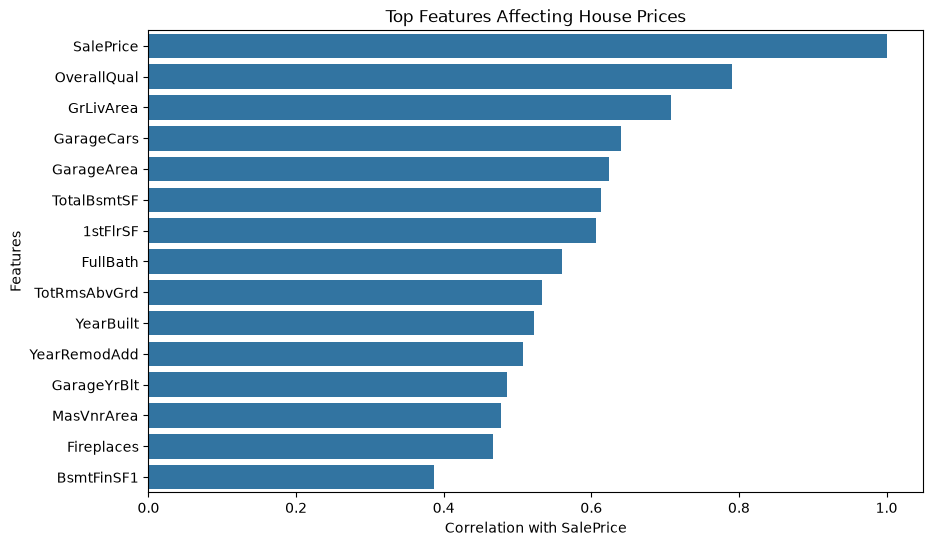

In [48]:
# Purpose:
# Visualize the top features most strongly
# correlated with SalePrice.

top_corr = (
    df.corr(numeric_only=True)["SalePrice"]
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_corr.values,
    y=top_corr.index

)

plt.xlabel("Correlation with SalePrice")
plt.ylabel("Features")
plt.title("Top Features Affecting House Prices")

plt.show()

### Why is OverallQual Important?

- Houses with better overall quality tend to have higher sale prices.
---

### Why is GarageCars Important?

- Houses with larger garage capacity generally sell for higher prices.
---

### Why is GrLivArea Important?

- Houses with larger living areas generally have higher sale prices.
---

## **Step 13: SalePrice Outlier Detection**

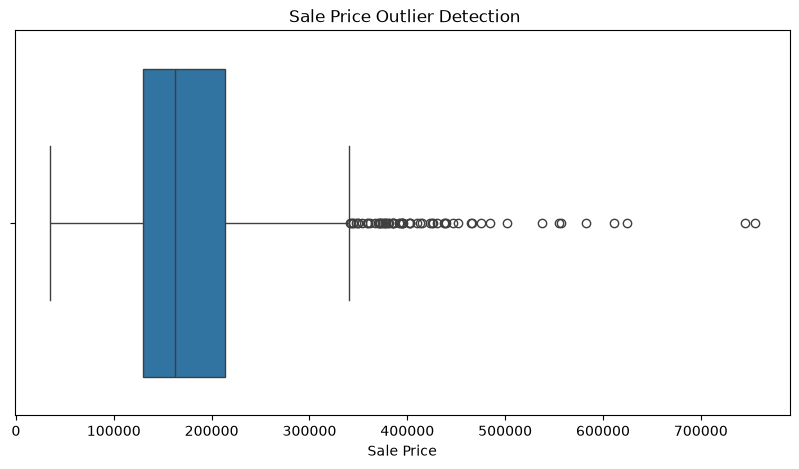

In [49]:
# Purpose:
# Detect unusual houses with extremely
# high or low prices

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["SalePrice"]
)

plt.xlabel("Sale Price")
plt.title(" Sale Price Outlier Detection")

plt.show()

### Are there luxury mansions?

✅ Yes.

The boxplot shows several houses with prices far above the typical price range, indicating the presence of luxury properties in the dataset.

---

### Are there extremely expensive houses?

✅ Yes.

A number of houses have SalePrice values above the upper whisker, with some reaching approximately \$700,000-\$755,000.

These are considered high-price outliers compared to the majority of houses.

---

### Should they be investigated later?

✅ Yes.

These extreme values should be investigated during feature analysis and outlier handling.

Before removing them, we should verify whether they represent:

- Genuine luxury houses
- Data entry errors
- Unusual property characteristics

Since expensive houses are realistic in real estate datasets, they should not be removed without proper investigation.

--- 

##  **Step 14: Overall Quality vs SalePrice**

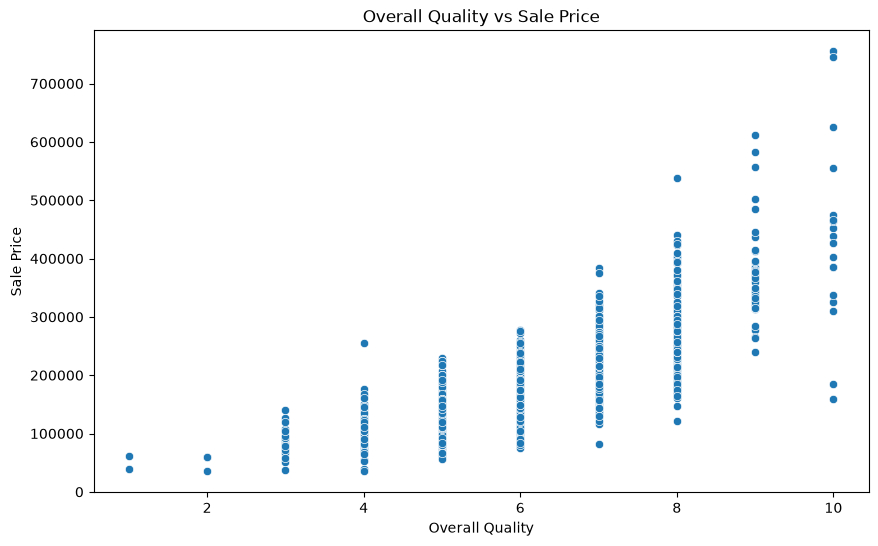

In [51]:
# Purpose:
# Check how house quality impacts price.

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Overall Quality vs Sale Price")

plt.show()

## **Conclusion**

- Houses with higher quality ratings tend to sell for higher prices.
---
- There is a strong positive relationship between OverallQual and SalePrice.
---
- OverallQual appears to be one of the most important features for predicting house prices.
---

##  **Step 15: Living Area vs SalePrice**

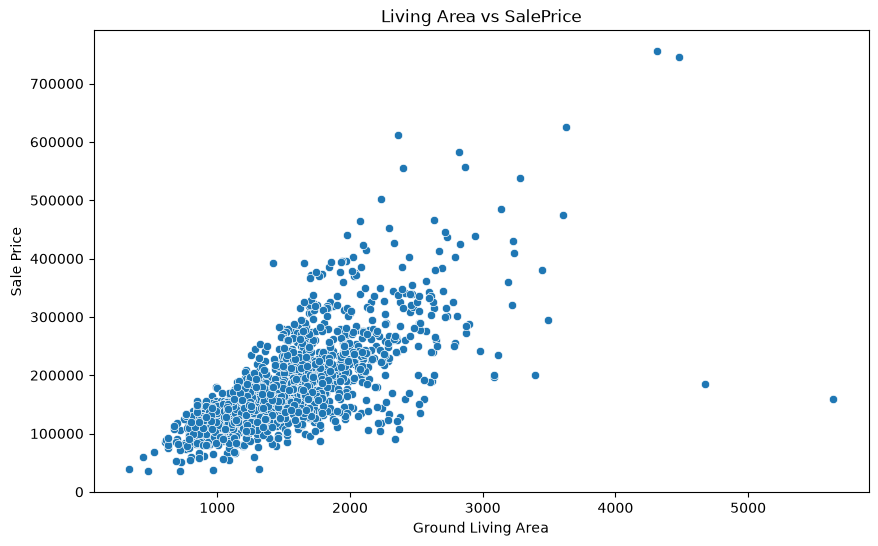

In [52]:
# Purpose:
# Check relationship between
# living area and house price.

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs SalePrice")

plt.show()

# **Conclusion**

- Houses with larger living areas generally sell for higher prices.
---
- There is a strong positive relationship between GrLivArea and SalePrice.
---
- A few unusual houses appear to be outliers and should be investigated during data cleaning.
---